# Fairness Paper Datasets for Example Code: Partially synthetic heart disease dataset

This Notebook contains an example illustrating the pipeline of fairness evaluation and bias mitigation in the medical domain. Note that the purpose of this example is not to develop a clinical prediction model for real-life applications but to underline the process of protected feature analysis. The dataset used is the heartdisease_tbl_df dataset, which stems from the R package CardioDataSets <https://cran.r-project.org/web/packages/CardioDataSets/index.html>. heartdisease_tbl_df, containing information on individuals assessed for heart disease, is a cleaned version of the original "Heart Disease" dataset from the UCI Machine Learning Repository (Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.). 

In order to generate an example health-related dataset for our tutorial, we modified the original heartdisease_tbl_df dataset by simulating data for additional patients (i.e., synthetically oversampling specific subgroups).Thus, the dataset used in our paper is a partially synthetic dataset generated based on the heartdisease_tbl_df dataset.  

**Age:** of the individual (numeric)

**Sex:** Sex of the individual (factor with 2 levels: typically "Male" and "Female")

**ChestPain:** Type of chest pain experienced (factor with 4 levels)

**BP:** Resting blood pressure (numeric)

**Cholesterol:** Serum cholesterol in mg/dl (numeric)

**BloodSugar:** Indicates if fasting blood sugar > 120 mg/dl (logical)

**MaximumHR:** Maximum heart rate achieved (numeric)

**ExerciseInducedAngina:** Exercise-induced angina (factor with 2 levels)

**HeartDisease:** Presence or absence of heart disease (factor with 2 levels) **(proposed outcome)**

In the following, you will find:

- Preliminary steps of setting up the example dataset for analysis
- *NEW* Intentionally oversampling men with heart disease to create "more unfair" dataset better to examplify methods
- Exploratory data analysis (EDA) of the outcome and protected feature distributions
- Example of embedding performance and fairness metrics into internal validation (here, repeated nested cross-validation) of a clinical statistical learning model predicting coronary heart diseases status from demographic/ basic clinical information
- Implementation of bias mitigation methods to identify the optimal fairness-aware model pipeline

## Preliminaries

In [121]:
# Import libraries
from joblib import dump, load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
%matplotlib inline

# To see all column names, change pandas options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [123]:
# Load CVD dataset (from R package CardioDataSets)
data1 = pd.read_csv("heartdisease_tbl_df.csv")
data1.head()

,Age,Sex,ChestPain,BP,Cholesterol,BloodSugar,MaximumHR,ExerciseInducedAngina,HeartDisease
0,63,Male,Typical angina,145,233,True,150,No,No
1,67,Male,Asymptomatic,160,286,False,108,Yes,Yes
2,67,Male,Asymptomatic,120,229,False,129,Yes,Yes
3,37,Male,Non-anginal pain,130,250,False,187,No,No
4,41,Female,Atypical angina,130,204,False,172,No,No


## Overview of OG dataset + data cleaning

In [126]:
# Understand the length and width of the dataset (randomised participants only)
print("The shape of the cardio dataset is : ", data1.shape)

The shape of the cardio dataset is :  (303, 9)


In [128]:
# Check for missing values (dataset was imputed for previous projects)
# Get precise missing value counts per variable:
data1.isnull().sum()

Age                      0
Sex                      0
ChestPain                0
BP                       0
Cholesterol              0
BloodSugar               0
MaximumHR                0
ExerciseInducedAngina    0
HeartDisease             0
dtype: int64

In [130]:
# Create deep copy so that original dataset unaffected
cardio = data1.copy()
cardio.shape

(303, 9)

In [132]:
# Create male variable (expected protected feature)
cardio['Sex_Male'] = cardio['Sex'].apply(lambda x: 1 if x == 'Male' else 0)

# Check variable was created correctly
cardio[["Sex", "Sex_Male"]].head(7)

,Sex,Sex_Male
0,Male,1
1,Male,1
2,Male,1
3,Male,1
4,Female,0
5,Male,1
6,Female,0


In [134]:
# Recode other binary vars: 'BloodSugar','ExerciseInducedAngina', 'HeartDisease'
cardio['HighBloodSugar'] = cardio['BloodSugar'].apply(lambda x: 1 if x == True else 0)
cardio['ExerciseInducedAngina'] = cardio['ExerciseInducedAngina'].apply(lambda x: 1 if x == 'Yes' else 0)
cardio['HeartDisease'] = cardio['HeartDisease'].apply(lambda x: 1 if x == 'Yes' else 0)
print(cardio['HighBloodSugar'].value_counts())
print(cardio['ExerciseInducedAngina'].value_counts())
print(cardio['HeartDisease'].value_counts())

HighBloodSugar
0    258
1     45
Name: count, dtype: int64
ExerciseInducedAngina
0    204
1     99
Name: count, dtype: int64
HeartDisease
0    164
1    139
Name: count, dtype: int64


In [136]:
# One hot encoding of categorical variable
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output = False) 

# Selecting the columns to be one hot encoded
ohe_cols = ['ChestPain']

# One hot encoding the categorical columns of the dataframes
ohe = encoder.fit_transform(cardio[ohe_cols])

# Getting the new names of the columns
col_names = encoder.get_feature_names_out(ohe_cols)

# Turning the encoded columns into dataframes
ohe_df = pd.DataFrame(ohe, columns=col_names, index=cardio.index)

## Drop
cardio_clean = cardio.copy()
cardio_clean.drop(['ChestPain', 'BloodSugar', 'Sex'], axis=1, inplace=True)
cardio_clean = pd.concat([ohe_df, cardio_clean], axis=1)

In [138]:
# See number of participants per outcome class
print(cardio_clean['HeartDisease'].value_counts())

HeartDisease
0    164
1    139
Name: count, dtype: int64


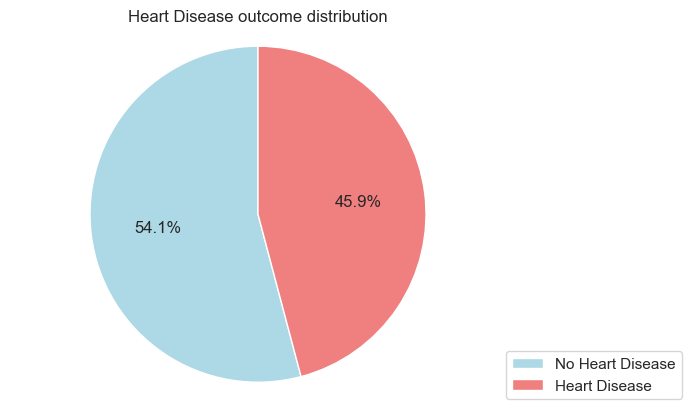

In [140]:
# Create a pie-plot visualising outcome class distribution
labels = ["No Heart Disease", "Heart Disease"] # Create labels
plt.pie(cardio_clean[["HeartDisease"]].value_counts(), autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90)
plt.axis('equal')
plt.legend( loc = (1,0), labels=labels) # Add legend
plt.title("Heart Disease outcome distribution") # Title
plt.show()

In [142]:
# Overview sex variable: more men than women
print(cardio_clean['Sex_Male'].value_counts())
print(cardio_clean['Sex_Male'].value_counts(normalize=True))

Sex_Male
1    206
0     97
Name: count, dtype: int64
Sex_Male
1    0.679868
0    0.320132
Name: proportion, dtype: float64


In [144]:
# Explore sex by mortality outcome: create cross-table to display (im)balance
cardio_clean[["Sex_Male", "HeartDisease"]].groupby("Sex_Male").value_counts(normalize=True)

Sex_Male  HeartDisease
0         0               0.742268
          1               0.257732
1         1               0.553398
          0               0.446602
Name: proportion, dtype: float64

In [146]:
cardio_clean[["Sex_Male", "HeartDisease"]].groupby("Sex_Male").value_counts()

Sex_Male  HeartDisease
0         0                72
          1                25
1         1               114
          0                92
Name: count, dtype: int64

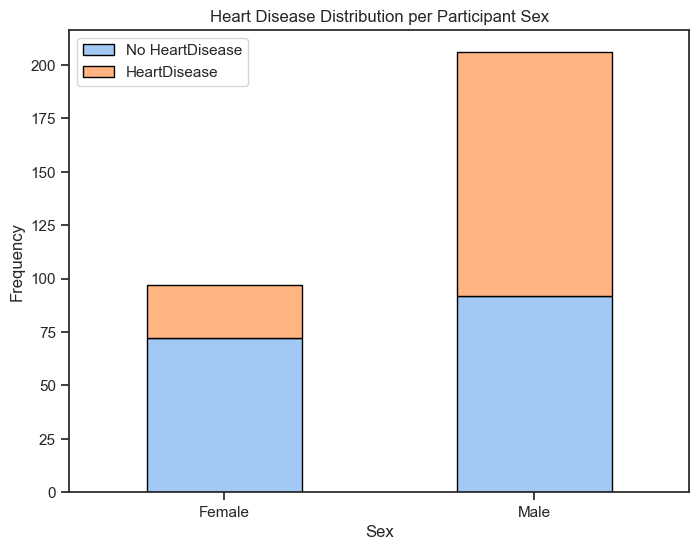

In [148]:
# Cross-tabulation of sex and HeartDisease
sex_y_counts = pd.crosstab(cardio_clean['Sex_Male'], cardio_clean['HeartDisease'])

# Set the seaborn theme
sns.set_theme(style = "ticks", palette = "pastel")

# Plot remission outcomes per sex
sex_y_counts.plot(kind='bar', stacked=True, figsize=(8, 6), edgecolor='black')
plt.title('Heart Disease Distribution per Participant Sex') # Add Title
plt.xlabel('Sex') # Label axes
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.legend(['No HeartDisease', 'HeartDisease']) # Legend
plt.show()

While there is an association between sex and heart disease, models based on this data did not delvier useful metrics for example. Will use oversampling to exaggerate the differences.

## Oversampling using SMOTE NC

Oversample both men with heart disease and women without heart disease

In [153]:
# OVERSAMPLE MALE with HEARTDISEASE == 1 
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder

In [155]:
# Define aspects of oversampling: easier when trying on different datasets
PF_COL = "Sex_Male"        
TARGET_COL = "HeartDisease"    
MALE_LABEL = 1              
TARGET_RATIO = 0.5 # desired proportion of (male, HeartDisease=1) in final dataset

# Define variable for male group value
MALE_ENCODED = 1     

# Make copy of subset before oversampling
df_enc = cardio_clean.copy()

# Define categorical variables for SMOTENC
categorical = ['ChestPain_Asymptomatic', 'ChestPain_Atypical angina','ChestPain_Non-anginal pain', 
               'ChestPain_Typical angina', 'ExerciseInducedAngina', 'Sex_Male','HighBloodSugar']

# Print current distribution of subgroups
print("Original distribution:\n",
      df_enc.groupby([PF_COL, TARGET_COL]).size(), "\n")

Original distribution:
 Sex_Male  HeartDisease
0         0                72
          1                25
1         0                92
          1               114
dtype: int64 



In [157]:
# Function to generate a compound target label for SMOTENC to only oversample specific subgroups
#   0 = female, hd=0
#   1 = female, hd=1
#   2 = male,   hd=0
#   3 = male,   hd=1 

def make_compound_label(row):
    if row[PF_COL] == MALE_ENCODED and row[TARGET_COL] == 1:
        return 3
    elif row[PF_COL] == MALE_ENCODED and row[TARGET_COL] == 0:
        return 2
    elif row[PF_COL] != MALE_ENCODED and row[TARGET_COL] == 1:
        return 1
    else:
        return 0

# Apply compound label function to generate compound label
compound_y = df_enc.apply(make_compound_label, axis=1)
print("Compound group counts before oversampling:\n", compound_y.value_counts(), "\n")

Compound group counts before oversampling:
 3    114
2     92
0     72
1     25
Name: count, dtype: int64 



In [159]:
# Build feature matrix
X = df_enc.copy()   

# Indices of categorical columns inside X for SMOTENC
all_cols = list(X.columns)
cat_indices = [all_cols.index(c) for c in categorical if c in all_cols]

print(cat_indices)

[0, 1, 2, 3, 8, 10, 11]


In [161]:
# Set up oversampling strategy
n_total_current = len(df_enc)
n_group3_current = (compound_y == 3).sum() # present size of male-hd subgroup
n_not3 = n_total_current - n_group3_current
n_group0_current = (compound_y == 0).sum() # present size of women no hd subgroup

# Solve: n_group3_new / (n_not3 + n_group3_new) = TARGET_RATIO for men with HD
n_group3_target = int(np.round(TARGET_RATIO * n_not3 / (1 - TARGET_RATIO)))
n_group3_target = max(n_group3_target, n_group3_current) 

# For oversampling women without heart diseasae: current count is 72, increase to 122
n_group0_target = 110

sampling_strategy = {
    0: n_group0_target,   # oversample
    1: (compound_y == 1).sum(),   # unchanged
    2: (compound_y == 2).sum(),   # unchanged
    3: n_group3_target            # oversample to desired count
}

print(f"Target count for (male, HeartDisease=1): "
      f"{n_group3_current} → {n_group3_target}")
print(f"Target count for (female, HeartDisease=0): "
      f"{n_group0_current} → {n_group0_target}")

# Apply SMOTENC to oversample subgroup of interest
smote = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5
)

# Fit and resample with SMOTE
X_res, y_res = smote.fit_resample(X, compound_y)

# Put dataframe back together
df_resampled = pd.DataFrame(X_res, columns=all_cols)
df_resampled.head()

print("\nDistribution after oversampling:")
print(df_resampled.groupby([PF_COL, TARGET_COL]).size())

Target count for (male, HeartDisease=1): 114 → 189
Target count for (female, HeartDisease=0): 72 → 110

Distribution after oversampling:
Sex_Male  HeartDisease
0         0               110
          1                25
1         0                92
          1               189
dtype: int64


## EDA of potential fairness example dataset

In [165]:
# Distribution of outcome variable
# See proportion of participants per outcome class
print(df_resampled['HeartDisease'].value_counts())
print("----------------------------------")
df_resampled[["HeartDisease"]].value_counts(normalize=True)

HeartDisease
1    214
0    202
Name: count, dtype: int64
----------------------------------


HeartDisease
1               0.514423
0               0.485577
Name: proportion, dtype: float64

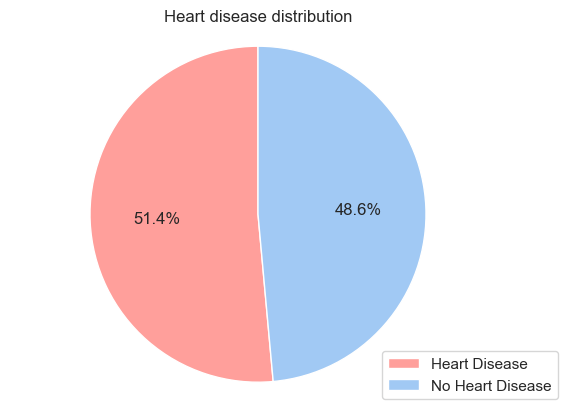

In [187]:
# Create a pie-plot visualising outcome class distribution
# Set the seaborn theme
sns.set_theme(style = "ticks", palette = "pastel")
labels = ["Heart Disease", "No Heart Disease"] # Create labels
plt.pie(df_resampled[["HeartDisease"]].value_counts(), colors=["#ff9f9b", "#a1c9f4"] , autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.legend( loc = (0.75,0), labels=labels) # Add legend
plt.title("Heart disease distribution") # Title
plt.savefig('outcome_pie.png')
plt.show();

In [169]:
# Distribution of sex variable
# See proportion of participants per outcome class
print(df_resampled['Sex_Male'].value_counts())
print("----------------------------------")
df_resampled[["Sex_Male"]].value_counts(normalize=True)

Sex_Male
1    281
0    135
Name: count, dtype: int64
----------------------------------


Sex_Male
1           0.675481
0           0.324519
Name: proportion, dtype: float64

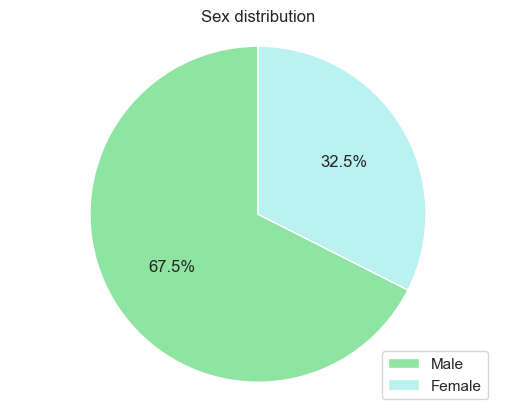

In [189]:
# Create a pie-plot visualising protected feature distribution
labels = ["Male", "Female"] # Create labels
plt.pie(df_resampled[["Sex_Male"]].value_counts(), autopct='%1.1f%%', colors=['#8de5a1', '#b9f2f0'], startangle=90)
plt.axis('equal')
plt.legend( loc = (0.75,0), labels=labels) # Add legend
plt.title("Sex distribution") # Title
plt.savefig('sex_pf_pie.png')
plt.show();

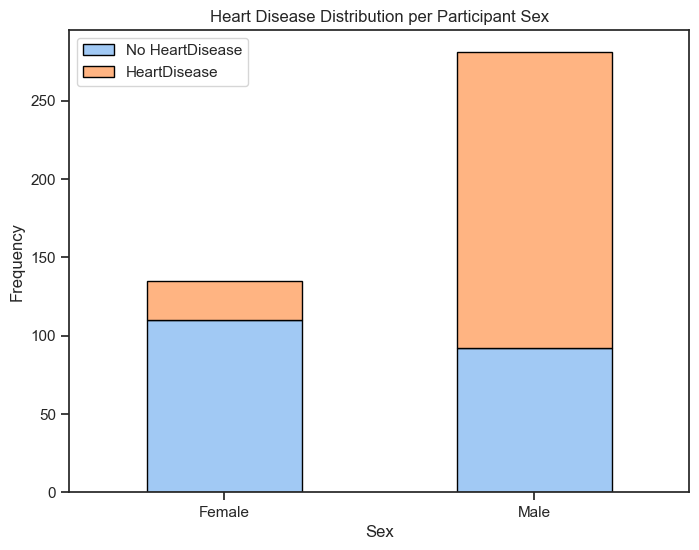

In [177]:
# Cross-tabulation of sex and HeartDisease
sex_y_counts = pd.crosstab(df_resampled['Sex_Male'], df_resampled['HeartDisease'])

# Plot remission outcomes per sex
sex_y_counts.plot(kind='bar', stacked=True, figsize=(8, 6), edgecolor='black')
plt.title('Heart Disease Distribution per Participant Sex') # Add Title
plt.xlabel('Sex') # Label axes
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.legend(['No HeartDisease', 'HeartDisease']) # Legend
plt.savefig('heartdisease_by_sex.png')
plt.show();

In [181]:
# Explore sex by mortality outcome: create cross-table to display (im)balance
print(df_resampled[["Sex_Male", "HeartDisease"]].groupby("Sex_Male").value_counts())
print("----------------------------------")
print(df_resampled[["Sex_Male", "HeartDisease"]].groupby("Sex_Male").value_counts(normalize=True))

Sex_Male  HeartDisease
0         0               110
          1                25
1         1               189
          0                92
Name: count, dtype: int64
----------------------------------
Sex_Male  HeartDisease
0         0               0.814815
          1               0.185185
1         1               0.672598
          0               0.327402
Name: proportion, dtype: float64


In [183]:
# Quantify differences using Chi-Square Tests of Indepedence between sex and death
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df_resampled['HeartDisease'], df_resampled['Sex_Male'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print results and matching message
print(f"Chi2 Statistic = {chi2:.3f}, p-value = {p:.3f}")
if p < 0.05:
    print("=> Statistically significant association between sex and HeartDisease.")
else:
    print("=> No statistically significant association between sex and HeartDisease.")

Chi2 Statistic = 84.788, p-value = 0.000
=> Statistically significant association between sex and HeartDisease.


## Benchmark elastic net model

In [130]:
# Import libraries
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from sklearn.preprocessing import OneHotEncoder
from aif360.algorithms.preprocessing import Reweighing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, recall_score, f1_score, confusion_matrix
from joblib import dump, load
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold, GridSearchCV)
from aif360.datasets import BinaryLabelDataset
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [132]:
# More preprocessing: Assign predictor columns to X and outcome to y
X = df_resampled.loc[:, df_resampled.columns != 'HeartDisease']
y = df_resampled['HeartDisease'] 
X.head()

,ChestPain_Asymptomatic,ChestPain_Atypical angina,ChestPain_Non-anginal pain,ChestPain_Typical angina,Age,BP,Cholesterol,MaximumHR,ExerciseInducedAngina,Sex_Male,HighBloodSugar
0,0.0,0.0,0.0,1.0,63,145,233,150,0,1,1
1,1.0,0.0,0.0,0.0,67,160,286,108,1,1,0
2,1.0,0.0,0.0,0.0,67,120,229,129,1,1,0
3,0.0,0.0,1.0,0.0,37,130,250,187,0,1,0
4,0.0,1.0,0.0,0.0,41,130,204,172,0,0,0


In [134]:
# FUNCTION FOR PRE-PROCESSING STEPS:
    # 1. Remove predictors with variance == 0
    # 2. Scale continuous predictors using StandardScaler
    # 3. Return pre-processed train and test sets

# Using pipeline would complicate modelling process due to hyperparameter naming requirements. Write function for preprocessing
# instead to call within cross-validation for each fold (in hyperparameter tuning). Secondly, do not want to scale binary variables.
def prepare_model(X_train, X_test):
    # VarianceThreshold: Remove features with zero variance 
    selector = VarianceThreshold()
    vt_train = selector.fit_transform(X_train)
    vt_test = selector.transform(X_test)
    
    # Save column names (in case some were dropped) for converting array to dataframe again
    col_names = selector.get_feature_names_out()
    vt_train_df = pd.DataFrame(vt_train, columns=col_names, index=X_train.index)
    vt_test_df = pd.DataFrame(vt_test, columns=col_names, index=X_test.index)
    
    # Make dataframe binary variable columns to NOT use for scaling
    binary_var = ['ChestPain_Asymptomatic', 'ChestPain_Atypical angina','ChestPain_Non-anginal pain', 
                  'ChestPain_Typical angina', 'ExerciseInducedAngina', 'Sex_Male','HighBloodSugar'] 
    
    # Extract names of columns of binary variables if not dropped by VarianceThreshold 
    binary_cols = []
    for i in col_names:
        if i in binary_var:
            binary_cols.append(i)
    # Create dataframe of binary variables only:        
    binary_train_df = vt_train_df[binary_cols].astype(int)
    binary_test_df = vt_test_df[binary_cols].astype(int)
    
    # List of numerical variables to be scaled
    scale_cols = [col for col in col_names if col not in binary_cols]
            
    # StandardScaler: Scale continuous features
    scaler = StandardScaler()
    trans_train = scaler.fit_transform(vt_train_df[scale_cols])
    trans_test = scaler.transform(vt_test_df[scale_cols])
    
    # Transform arrays of scaled columns back to DataFrames
    train_tf = pd.DataFrame(trans_train, columns=scale_cols, index=X_train.index)
    test_tf = pd.DataFrame(trans_test, columns=scale_cols, index=X_test.index)
    
    # Merge binary variables and scaled variables back together
    X_train_tf = pd.concat([binary_train_df, train_tf], axis = 1)
    X_test_tf = pd.concat([binary_test_df, test_tf], axis = 1)
    return X_train_tf, X_test_tf

In [136]:
# FUNCTION TO PERFORM HYPERPARAMETER TUNING IN CROSS-VALIDATION (elastic net):
def tune_elastic_net(X_train, y_train, sample_weight, random_state, i):
    
    # Initiate elastic net model with balanced class weights
    model = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=100000, class_weight='balanced', random_state=random_state, n_jobs=1)
    
    # Define stratified split function (5 splits)
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
    # Define search grid (AUC evaluated)
    grid_search = GridSearchCV(model, params, scoring='roc_auc', n_jobs=9, cv=kfold, verbose=1)
    
    # Fit search grid: Run hyperparameter tuning
    grid_result = grid_search.fit(X_train, y_train)
    
    # Print best score (AUC) and best hyperparameters
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    
    # Fitting best model of iteration to the training data, allows for inclusion of instance weights 'sample_weight' (as created by reweighing)
    elnet_opt = LogisticRegression(penalty='elasticnet', solver='saga', **grid_result.best_params_, random_state=random_state, max_iter=100000, class_weight='balanced')
    elnet_opt = elnet_opt.fit(X_train, y_train, sample_weight=sample_weight)
    return elnet_opt

In [138]:
# Scoring functions for performance evaluation 
# (from Ewan Carr <https://github.com/ewancarr/tda-prediction/blob/main/functions.py>)

# False positives
def fp(y_true, y_proba, threshold=0.5):
    y_pred = y_proba > threshold
    return(confusion_matrix(y_true, y_pred)[0, 1])

# False negatives
def fn(y_true, y_proba, threshold=0.5):
    y_pred = y_proba > threshold
    return(confusion_matrix(y_true, y_pred)[1, 0])

# True positives
def tp(y_true, y_proba, threshold=0.5):
    y_pred = y_proba > threshold
    return(confusion_matrix(y_true, y_pred)[1, 1])

# True negatives
def tn(y_true, y_proba, threshold=0.5):
    y_pred = y_proba > threshold
    return(confusion_matrix(y_true, y_pred)[0, 0])

# Negative predictive value (NPV)
def calc_npv(y_true, y_prob, threshold=0.5):
    y_pred = y_prob > threshold
    n_tn = int(tn(y_true, y_pred))
    n_fn = int(fn(y_true, y_pred))
    if n_tn == 0:
        npv = np.nan
    else:
        with np.errstate(invalid='ignore'):
            npv = np.mean(n_tn / (n_tn + n_fn))
    return(npv)

# Positive predictive value (PPV)
def calc_ppv(y_true, y_prob, threshold=0.5):
    y_pred = y_prob > threshold
    n_tp = int(tp(y_true, y_pred))
    n_fp = int(fp(y_true, y_pred))
    if n_tp == 0:
        ppv = np.nan
    else:
        with np.errstate(invalid='ignore'):
            ppv = np.mean(n_tp / (n_tp + n_fp))
    return(ppv)

In [140]:
# Helper functions for internal validation; 
# adapted from Dang et al. (2024) <https://github.com/ngoc-vien-dang/FairML-Depression/blob/main/FairML/utils/helper.py>
def evaluate_class_mdl(fitted_model, X_train, X_test, y_train, y_test,predopts={},threshold = 0.5):
    # Initialise dictionary
    eval_dict = {}
    y_train_pred = fitted_model.predict(X_train, **predopts).squeeze()
    # Get predicted probabilities, predicted label, true label (control for case where categorical (not binary) outcome
    if len(np.unique(y_train_pred)) > 2:
        y_test_prob = fitted_model.predict(X_test, **predopts).squeeze()
        y_test_pred = np.where(y_test_prob > threshold, 1, 0)
    else:   
        y_test_prob = fitted_model.predict_proba(X_test, **predopts)[:,1]
        y_test_pred = np.where(y_test_prob > threshold, 1, 0)
    return evaluate_class_metrics_mdl(y_test_prob, y_test_pred, y_test)

# Get performance metrics for model 
def evaluate_class_metrics_mdl(y_test_prob, y_test_pred, y_test):      
    eval_dict = {}
    # Store predicted label and predicted probability of outcome = 1
    eval_dict['probs_test'] = y_test_prob
    eval_dict['preds_test'] = y_test_pred
    # Store performance metrics
    eval_dict['roc_auc_test'] = roc_auc_score(y_test, y_test_prob) # AUC
    eval_dict['bacc_test'] = balanced_accuracy_score(y_test, y_test_pred) # Balanced accuracy
    eval_dict['acc_test'] = accuracy_score(y_test, y_test_pred) # Accuracy
    #eval_dict['TP'] = tp(y_test, y_test_prob) # True positives
    #eval_dict['TN'] = tn(y_test, y_test_prob) # True negatives
    #eval_dict['FP'] = fp(y_test, y_test_prob) # False positives
    #eval_dict['FN'] = fn(y_test, y_test_prob) # False negatives
    eval_dict['sensitivity'] = recall_score(y_test, y_test_pred) # Sensitivity
    eval_dict['specificity'] = recall_score(y_test, y_test_pred, pos_label=0) # Specificity
    eval_dict['precision'] = calc_ppv(y_test, y_test_prob) # PPV / precision
    eval_dict['f1_score'] = f1_score(y_test, y_test_pred)  # F1 score
    eval_dict['NPV'] = calc_npv(y_test, y_test_prob) # NPV
    return eval_dict

In [142]:
# AIF360 fairness metrics function: adapted from Dang et al. (2024). 
# <https://github.com/ngoc-vien-dang/FairML-Depression/blob/main/FairML/utils/helper.py>
def compute_aif_metrics(dataset_true, dataset_pred, unprivileged_groups, privileged_groups):

    metrics_cls = ClassificationMetric(dataset_true, dataset_pred, 
                                       unprivileged_groups=unprivileged_groups,
                                       privileged_groups=privileged_groups)
    metrics_dict = {}
    # Disparate impact
    metrics_dict["DI"] = metrics_cls.disparate_impact()
    # Equal opportunity difference
    metrics_dict["EOD"] = metrics_cls.equal_opportunity_difference()
    # Average odds difference
    metrics_dict["AOD"] = metrics_cls.average_odds_difference()
    # Statistical parity difference
    metrics_dict["SPD"] = metrics_cls.statistical_parity_difference()
    
    return metrics_dict, metrics_cls

# Function to prepare subgroups for performance metrics by subgroup (from Dang et al. (2024))
# <https://github.com/ngoc-vien-dang/FairML-Depression/blob/main/FairML/utils/helper.py>
def compute_boolean_conditioning_vector(X,condition=None):
    feature_names = X.columns.tolist()
    X = X.to_numpy()
    overall_cond = np.zeros(X.shape[0], dtype=bool)
    for group in condition:
        group_cond = np.ones(X.shape[0], dtype=bool)
        for name, val in group.items():
            index = feature_names.index(name)
            group_cond = np.logical_and(group_cond, X[:, index] == val)
        overall_cond = np.logical_or(overall_cond, group_cond)
    return overall_cond

# Function to compute performance metrics per subgroup (adapted from Dang et al. (2024))
# <https://github.com/ngoc-vien-dang/FairML-Depression/blob/main/FairML/utils/helper.py>
def performance_measures(X, y_true, y_pred, positive_label, negative_label, condition, group):
    class_rate_dict = {}
    w = np.ones(X.shape[0], dtype=int)
    cond_vec = compute_boolean_conditioning_vector(X,condition)
    # to prevent broadcasts
    y_true = pd.Series.to_numpy(y_true)
    y_pred = y_pred.ravel()

    y_true_pos = (y_true == positive_label)
    y_true_neg = (y_true == negative_label)
    y_pred_pos = np.logical_and(y_pred == positive_label, cond_vec)
    y_pred_neg = np.logical_and(y_pred == negative_label, cond_vec)

    # True/false positives/negatives
    TP = np.sum(w[np.logical_and(y_true_pos, y_pred_pos)], dtype=np.float64)
    FP = np.sum(w[np.logical_and(y_true_neg, y_pred_pos)], dtype=np.float64)
    TN = np.sum(w[np.logical_and(y_true_neg, y_pred_neg)], dtype=np.float64)
    FN = np.sum(w[np.logical_and(y_true_pos, y_pred_neg)], dtype=np.float64)
    P=TP + FN; N=TN + FP

    # Compute and store TPR, TNR, FPR, and FNR for each subgroup of protected feature
    class_rate_dict['tpr'+'_'+ group]= TP / P
    class_rate_dict['tnr'+'_'+ group]= TN / N
    class_rate_dict['fpr'+'_'+ group]= FP / N
    class_rate_dict['fnr'+'_'+ group]= FN / P
    # True positive rate (recall) by subgroup)
    class_rate_dict['tpr'+'_'+ group]= TP / P
    # Accuracy by subgroup
    class_rate_dict['acc'+'_'+ group]= (TN + TP) / (P + N)
    # Balanced accuracy by subgroup
    class_rate_dict['bacc'+'_'+ group] = 0.5 * ( (TP / P) + (TN / N) )
    return class_rate_dict

In [144]:
# Function to benchmark baseline model: audit algroithmic bias. Adapted from Dang et a. (2024)
# <https://github.com/ngoc-vien-dang/FairML-Depression/blob/main/FairML/algorithms/benchmark/benchmark.py>
def benchmark(X_train, y_train, X_test, y_test, cls_mdls, fitted_model, unprivileged_groups, privileged_groups,
              conditions, label_name, protected_attribute_name, protected_attribute_values, i, sup=[]):
    
    # Convert training set into BinaryLabelDataset for AIF360 functions
    train_ds = BinaryLabelDataset(df=X_train.join(y_train),
                                  label_names=[label_name],
                                  protected_attribute_names=[protected_attribute_name],
                                  favorable_label=1, unfavorable_label=0)
    
    # Convert test set into BinaryLabelDataset for AIF360 functions
    test_ds = BinaryLabelDataset(df=X_test.join(y_test),
                                 label_names=[label_name],
                                 protected_attribute_names=[protected_attribute_name],
                                 favorable_label=1, unfavorable_label=0)
    
    # Compute and store performance metrics in dict:
    # For AgeGroup protected feature: exclude new variable in performance metrics evaluation
    if sup:
        protected_index = [train_ds.feature_names.index(m) for m in sup]
        X_train_sup = np.delete(train_ds.features, protected_index, axis=1) # Suppress age group
        X_test_sup = np.delete(test_ds.features, protected_index, axis=1) # Suppress age group
        # Get performance and fairness metrics of baseline model
        cls_mdls['benchmark'+'_'+str(i)] = evaluate_class_mdl(fitted_model, X_train_sup, X_test_sup,  y_train, y_test) 
    else:
        # For binary protected features which are predictors: Get performance and fairness metrics of baseline model
        cls_mdls['benchmark'+'_'+str(i)] = evaluate_class_mdl(fitted_model, X_train, X_test, y_train, y_test)
    
    # Prepare datasets for fairness metrics: define predicted labels and probabilities
    test_pred_ds = test_ds.copy(deepcopy=True)
    test_pred_ds.labels = cls_mdls['benchmark'+'_'+str(i)]['preds_test'].reshape(-1,1)
    test_pred_ds.scores = cls_mdls['benchmark'+'_'+str(i)]['probs_test'].reshape(-1,1)
    y_pred = cls_mdls['benchmark'+'_'+str(i)]['preds_test'].reshape(-1,1)
    
    # Get fairness metrics using previously defined function
    metrics_test_dict, metrics_test_cls = compute_aif_metrics(test_ds, test_pred_ds,
                                                              unprivileged_groups=unprivileged_groups, 
                                                              privileged_groups=privileged_groups)
    # Store fairness metrics in dict
    cls_mdls['benchmark'+'_'+str(i)].update(metrics_test_dict)
    
    # Calculate confusion matrix cells for subgroups (per protected feature)
    for j,k in enumerate(protected_attribute_values):
        globals()[f'per_{k}'] = performance_measures(X_test,y_test,y_pred,1,0,conditions[j],k)
        # Store subgroup performance metrics in dict
        cls_mdls['benchmark'+'_'+str(i)].update(globals()[f'per_{k}'])
    return cls_mdls

In [146]:
# Define search grids of hyperparameters (lambda (C) and alpha (l1_ratio)

# Generate lambda search grid: 100 values from 0.001 to 4 (learnt in Prediction Modelling course) for parameter C
# a log spaced distribution of lambda (between 4.0 and almost 0) (adapted from R: i.e., 2^seq(from = 2, to = -10, length = 100))
c_grid = []
for i in range(-988, 212, 12):
    i = i / 100
    number = 2**i
    c_grid.append(number)
print(c_grid)
print(f"Length of lambda grid: {len(c_grid)}")

# Define search grid for l1_ratio (in LogisticRegression implementation: l1_ratio) where l1_ratio=1 is Lasso and l1_ratio=0 is Ridge regularisation
l1_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

params = {'C' : c_grid, 'l1_ratio' : l1_grid }

[0.001061264514185603, 0.001153313145927276, 0.001253345603088773, 0.0013620543616703182, 0.0014801919594828103, 0.0016085762056007294, 0.001748095841656196, 0.0018997166941646213, 0.0020644883604714463, 0.002243551474603583, 0.002438145603323461, 0.002649617827046233, 0.0028794320650216833, 0.0031291792093344605, 0.0034005881378754866, 0.003695537682521859, 0.00401606963537526, 0.0043644028830946095, 0.004742948767168152, 0.00515432777645662, 0.005601387687561824, 0.006087223278597654, 0.0066151977528322425, 0.0071889660205068364, 0.0078125, 0.00849011611348483, 0.009226505167418207, 0.010026764824710191, 0.010896434893362545, 0.011841535675862483, 0.012868609644805828, 0.013984766733249568, 0.015197733553316961, 0.01651590688377157, 0.017948411796828673, 0.01950516482658769, 0.02119694261636988, 0.02303545652017345, 0.025033433674675684, 0.027204705103003875, 0.02956430146017487, 0.03212855708300208, 0.034915223064756876, 0.03794359013734522, 0.04123462221165296, 0.04481110150049459,

In [148]:
# REPEATED NESTED CV: Protected Feature Sex
## QUICK VERSION

# Set seed for reproducibility 
np.random.seed(123) 

# Define repeats
repeats = 10 # ideally 100

# Make a list of random integers between 0 and 10000 of length = CV_repeats to act as different data splits
random_states = np.random.randint(1000, size=repeats) 

# Number of outer folds
outer_folds = 5

# REPETITION LOOP
for r, rep in enumerate(range(repeats)):
    # Verbose: print repetition number
    print('\n------------ CV Repeat number:', rep)

    # Define stratified split of outer loop for nested cross-validation
    k_fold = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=random_states[r])
    
    # Initialise empty dictionary to store results per fold of immediate outer loop
    cls_mdls = {}

    # OUTER LOOP: split data into training and test sets
    for i, (train_index, test_index) in enumerate(k_fold.split(X, y)): # X and y
        X_train, X_test = X.iloc[train_index], X.iloc[test_index] # Training / development set (HP tuning)
        y_train, y_test = y.iloc[train_index], y.iloc[test_index] # Test set (evaluation)
        
        # Prepare data for model
        X_train, X_test = prepare_model(X_train, X_test) 
        
        # INNER LOOP. Run 5-fold CV for hyperparameter tuning: returns best model re-fitted to training data
        elnet_opt = tune_elastic_net(X_train, y_train, None, random_states[r], i)
        # End inner loop.

        # Define variables for AIF360 functions
        # Privileged / unprivileged groups
        unprivileged_groups, privileged_groups=[{'Sex_Male': 0}], [{'Sex_Male': 1}]
        
        # Conditions (or subgroups) of protected attribute
        conditions = [[{'Sex_Male':0}],[{'Sex_Male':1}]]
        
        # Define outcome label name, protected attribute name
        label_name, protected_attribute_name = 'HeartDisease', 'Sex_Male'
        
        # Names of subgroups
        protected_attribute_values = ['Female','Male']
        
        # Store performance metrics of outer loop in dict: list with metrics per fold (1 dict with 5 lists per outer loop)
        cls_mdls = benchmark(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cls_mdls=cls_mdls, fitted_model=elnet_opt, 
                             unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups, conditions=conditions,
                             label_name=label_name, protected_attribute_name=protected_attribute_name, protected_attribute_values=protected_attribute_values,
                             i=i)

    # END OUTER LOOP
    # Make performance metrics dict a dataframe: plus name columns
    cls_metrics_df = pd.DataFrame.from_dict(cls_mdls, 'index')
    cls_metrics_df = cls_metrics_df.drop(['probs_test','preds_test'], axis=1)
    print(cls_metrics_df)
    
    # Average performance metrics over folds: Save as dataframe with 1 row per repetition. 
    if rep == 0:
        cls_metrics_means = cls_metrics_df.agg(['mean']).reset_index(drop=True) # Create target dataframe to append results to in 1st rep
    else:
        new_metrics = cls_metrics_df.agg(['mean']).reset_index(drop=True)
        cls_metrics_means = pd.concat([cls_metrics_means, new_metrics]) # Append new results until all reps completed
        del new_metrics

# Reset index so index reflects repetition number
cls_metrics_means = cls_metrics_means.reset_index(drop=True)

# Save results as DataFrame for future extraction
cls_metrics_means.to_csv('Results/TEST_HD_Elnet_NestedCV10_Metric_Means_Sex.csv', index=True)



------------ CV Repeat number: 0
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.913630 using {'C': 0.5904963307147651, 'l1_ratio': 1.0}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.918351 using {'C': 0.23651441168139897, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.919445 using {'C': 0.217637640824031, 'l1_ratio': 0.8}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.911286 using {'C': 0.6973718331752027, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.910878 using {'C': 0.27932178451805495, 'l1_ratio': 0.4}
             roc_auc_test  bacc_test  acc_test  sensitivity  specificity  \
benchmark_0      0.925128   0.869824  0.869048     0.837209     0.902439   
benchmark_1      0.897213   0.818815  0.819277     0.857143     0.780488   
benchmark_2      0.909302   0.807849  0.807229     0.790698     0.825000   
benchmark_3     

In [150]:
cls_metrics_means.describe()

,roc_auc_test,bacc_test,acc_test,sensitivity,specificity,precision,f1_score,NPV,DI,EOD,AOD,SPD,tpr_Female,tnr_Female,fpr_Female,fnr_Female,acc_Female,bacc_Female,tpr_Male,tnr_Male,fpr_Male,fnr_Male,acc_Male,bacc_Male
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.914366,0.837686,0.837281,0.827165,0.848207,0.853911,0.839215,0.824196,0.231787,-0.232216,-0.227060,-0.512375,0.622667,0.951056,0.048944,0.377333,0.886715,0.786861,0.854882,0.729153,0.270847,0.145118,0.813548,0.792018
std,0.002575,0.005833,0.005802,0.005817,0.012380,0.009643,0.004813,0.005234,0.019351,0.040458,0.018661,0.011157,0.038523,0.013401,0.013401,0.038523,0.012846,0.021523,0.005507,0.012116,0.012116,0.005507,0.004630,0.006991
min,0.909977,0.829422,0.829145,0.818162,0.827195,0.836579,0.832718,0.815667,0.206594,-0.270808,-0.245940,-0.527195,0.585714,0.932032,0.028860,0.278571,0.869536,0.765165,0.847066,0.706565,0.257976,0.133770,0.806448,0.780417
25%,0.912658,0.835355,0.834732,0.822591,0.838445,0.846975,0.835590,0.820517,0.215824,-0.249119,-0.236673,-0.520014,0.601488,0.939487,0.039234,0.374167,0.874940,0.774085,0.852201,0.721707,0.261204,0.142845,0.810416,0.786364
50%,0.914246,0.837043,0.836661,0.826910,0.849207,0.854343,0.840142,0.824100,0.232429,-0.244263,-0.231144,-0.513492,0.612619,0.954748,0.045252,0.387381,0.887812,0.783207,0.855396,0.732241,0.267759,0.144604,0.813372,0.792522
75%,0.915811,0.840992,0.840742,0.831755,0.856524,0.860548,0.840702,0.828695,0.239702,-0.226746,-0.229729,-0.508641,0.625833,0.960766,0.060513,0.398512,0.895852,0.793318,0.857155,0.738796,0.278293,0.147799,0.817621,0.797975
max,0.919003,0.848946,0.848566,0.836766,0.866220,0.868167,0.849062,0.831049,0.265575,-0.125637,-0.179494,-0.494403,0.721429,0.971140,0.067968,0.414286,0.907366,0.840169,0.866230,0.742024,0.293435,0.152934,0.820034,0.801205


In [152]:
# For sex: get performance and fairness metrics (medians and uncertainty intervals) of baseline model for report
cols = ['roc_auc_test', 'bacc_test', 'acc_test', 'sensitivity', 'specificity', 'f1_score', 'precision', 'NPV', 'EOD', 'AOD', 'DI', 'SPD']
for c in cols:
    print(c)
    p50, p2, p98 = np.percentile(cls_metrics_means[c], [50, 2.5, 97.5])
    print("Median:" + str(round(p50, 3)))  
    print("Lower 95% CI:" + str(round(p2, 3)))
    print("Upper 95% CI:" + str(round(p98, 3)))
    print("\n----------------------")

roc_auc_test
Median:0.914
Lower 95% CI:0.911
Upper 95% CI:0.918

----------------------
bacc_test
Median:0.837
Lower 95% CI:0.829
Upper 95% CI:0.847

----------------------
acc_test
Median:0.837
Lower 95% CI:0.829
Upper 95% CI:0.847

----------------------
sensitivity
Median:0.827
Lower 95% CI:0.819
Upper 95% CI:0.836

----------------------
specificity
Median:0.849
Lower 95% CI:0.829
Upper 95% CI:0.865

----------------------
f1_score
Median:0.84
Lower 95% CI:0.833
Upper 95% CI:0.847

----------------------
precision
Median:0.854
Lower 95% CI:0.839
Upper 95% CI:0.867

----------------------
NPV
Median:0.824
Lower 95% CI:0.816
Upper 95% CI:0.831

----------------------
EOD
Median:-0.244
Lower 95% CI:-0.269
Upper 95% CI:-0.148

----------------------
AOD
Median:-0.231
Lower 95% CI:-0.244
Upper 95% CI:-0.187

----------------------
DI
Median:0.232
Lower 95% CI:0.207
Upper 95% CI:0.264

----------------------
SPD
Median:-0.513
Lower 95% CI:-0.527
Upper 95% CI:-0.495

---------------------

## Bias mitigation example 1: reweighing

In [155]:
# REWEIGHING FUNCTION to embed AIF360 native reweighing function into repeated nested cross-validation
# adapted from Dang et al. (2024) <https://github.com/ngoc-vien-dang/FairML-Depression/blob/main/FairML/algorithms/preprocessing/rw.py>. 
# Note that the function written by Dang et al. (2024) as shown on their github was erroneous.
def reweighing(X_train, y_train, X_test, y_test, cls_mdls, unprivileged_groups, privileged_groups, conditions, label_name,
               protected_attribute_name, protected_attribute_values, i, model_func, random_state, sup=[]):
    
    # Convert training and test set into BinaryLabelDataset to use AIF360 fairness metrics and reweighing functions
    train_ds = BinaryLabelDataset(df=X_train.join(y_train), label_names=[label_name],
                                  protected_attribute_names=[protected_attribute_name],
                                  favorable_label=1, unfavorable_label=0)
    test_ds = BinaryLabelDataset(df=X_test.join(y_test), label_names=[label_name],
                                 protected_attribute_names=[protected_attribute_name],
                                 favorable_label=1, unfavorable_label=0)
    
    # Define reweighing function
    reweighter = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
    
    # Fit reweighing function to training set to compute the weights 
    reweighter.fit(train_ds)
    
    # Apply computed weightts to the training data (instance_weights added)
    train_rw_ds = reweighter.transform(train_ds)
    
    # For protected feature age (where age_group variable needs to be excluded from training), delete age_group
    if sup:
        # Delete age group columns (since not a predictor)
        protected_index = [train_ds.feature_names.index(m) for m in sup]
        X_train_sup = np.delete(train_rw_ds.features, protected_index, axis=1) # suppress age_group variable(s)
        X_test_sup = np.delete(test_ds.features, protected_index, axis=1) # suppress age_group variable(s)
        
        # Train model on reweighted training data: (X_train (without AgeGroup), y_train, sample_weight=instance_weights, random_state, i):
        model_opt = model_func(X_train_sup, train_rw_ds.labels.ravel(), train_rw_ds.instance_weights, random_state, i)
        
        # Store performance metrics
        cls_mdls['rw'+'_'+str(i)] = evaluate_class_mdl(model_opt, X_train_sup, X_test_sup, y_train, y_test)
    
    # For binary protected features, can directly fit model on train_ds 
    else:
        # Train model on reweighted training data
        model_opt = model_func(train_rw_ds.features, train_rw_ds.labels.ravel(), train_rw_ds.instance_weights, random_state, i)

        # Store performance metrics
        cls_mdls['rw'+'_'+str(i)] = evaluate_class_mdl(model_opt, train_rw_ds.features, test_ds.features, y_train, y_test)
    
    # Create new column for predicted labels in test set
    test_pred_ds = test_ds.copy(deepcopy=True)
    test_pred_ds.labels = cls_mdls['rw'+'_'+str(i)]['preds_test'].reshape(-1,1) 
    
    # Create new columns for predicted probabilities in test set
    test_pred_ds.scores = cls_mdls['rw'+'_'+str(i)]['probs_test'].reshape(-1,1)
    y_pred = cls_mdls['rw'+'_'+str(i)]['preds_test'].reshape(-1,1)
    
    # Get AIF fairness metrics
    metrics_test_dict, metrics_test_cls = compute_aif_metrics(test_ds, test_pred_ds, unprivileged_groups=unprivileged_groups, 
                                                              privileged_groups=privileged_groups)
    # Store fairness metrics
    cls_mdls['rw'+'_'+str(i)].update(metrics_test_dict)
    
    # Get TPR, FPR ... performance metrics per subgroup of protected feature
    for j,k in enumerate(protected_attribute_values):
        globals()[f'per_{k}'] = performance_measures(X_test,y_test,y_pred,1,0,conditions[j],k)
        # Store performance metrics by subgroup
        cls_mdls['rw'+'_'+str(i)].update(globals()[f'per_{k}'])
    return cls_mdls

In [157]:
# REPEATED NESTED CV with REWEIGHING: Protected Feature Sex

# Set seed for reproducibility 
np.random.seed(123) 

# Define repeats
repeats = 10

# Make a list of random integers between 0 and 10000 of length = CV_repeats to act as different data splits
random_states = np.random.randint(1000, size=repeats) 

# Number of outer folds
outer_folds = 7

# REPETITION LOOP
for r, rep in enumerate(range(repeats)):
    # Verbose: print repetition number
    print('\n------------ CV Repeat number:', rep)
    
    # Define stratified split of outer loop for nested cross-validation
    k_fold = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=random_states[r])
    
    # Initialise empty dictionary to store results per fold of immediate outer loop
    cls_mdls = {}

    # OUTER LOOP: split data into training and test sets
    for i, (train_index, test_index) in enumerate(k_fold.split(X,y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index] # Training set
        y_train, y_test = y.iloc[train_index], y.iloc[test_index] # Test set
        
        # Prepare data for model
        X_train, X_test = prepare_model(X_train, X_test)
        
        # Define privileged vs unpriviliged groups
        unprivileged_groups, privileged_groups=[{'Sex_Male': 0}], [{'Sex_Male': 1}]
        
        # Define conditions for boolean function (separate metrics per subgroup)
        conditions = [[{'Sex_Male':0}],[{'Sex_Male':1}]]
       
        # Define outcome and protected feature names
        label_name,protected_attribute_name = 'HeartDisease', 'Sex_Male'
        protected_attribute_values = ['Female', 'Male']
        
        # Define model development function: performs hyperparameter tuning in inner loop
        model_func = tune_elastic_net

        # Store performance metrics (outer loop) based on reweighed training data in dict: 
        # list with metrics per fold (1 dict with 5 lists per outer loop)
        cls_mdls = reweighing(X_train,y_train,X_test,y_test,cls_mdls,unprivileged_groups,privileged_groups,conditions,
                              label_name,protected_attribute_name,protected_attribute_values,i,model_func, random_states[r])
    
    # END OUTER LOOP
    # Make performance metrics dict a dataframe: plus name columns
    cls_metrics_df = pd.DataFrame.from_dict(cls_mdls, 'index')
    cls_metrics_df = cls_metrics_df.drop(['probs_test','preds_test'], axis=1)
    print(cls_metrics_df)

    # Average performance metrics over folds: Save as dataframe with 1 row per repetition. 
    if rep == 0:
        cls_metrics_means = cls_metrics_df.agg(['mean']).reset_index(drop=True)
    else:
        new_metrics = cls_metrics_df.agg(['mean']).reset_index(drop=True)
        cls_metrics_means = pd.concat([cls_metrics_means, new_metrics])
        del new_metrics

# Reset index so index reflects repetition number
cls_metrics_means = cls_metrics_means.reset_index(drop=True)

# Save results as DataFrame for future extraction
cls_metrics_means.to_csv('Results/TEST_RW10_Metric_Means_Sex.csv', index=True)



------------ CV Repeat number: 0
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.922239 using {'C': 0.757858283255199, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.918496 using {'C': 0.25702845666401664, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.924019 using {'C': 1.2483305489016119, 'l1_ratio': 0.8}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.906235 using {'C': 0.543367431263029, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.910386 using {'C': 0.9726549474122855, 'l1_ratio': 1.0}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.917293 using {'C': 0.4233726561812636, 'l1_ratio': 1.0}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.910222 using {'C': 0.27932178451805495, 'l1_ratio': 0.8}
      roc_auc_test  bacc_test  acc_test  sensitivity  specifici

/opt/anaconda3/lib/python3.12/site-packages/aif360/metrics/classification_metric.py:278: RuntimeWarning: invalid value encountered in scalar divide
  TPR=TP / P, TNR=TN / N, FPR=FP / N, FNR=FN / P,
/opt/anaconda3/lib/python3.12/site-packages/aif360/metrics/classification_metric.py:279: RuntimeWarning: invalid value encountered in scalar divide
  GTPR=GTP / P, GTNR=GTN / N, GFPR=GFP / N, GFNR=GFN / P,
/var/folders/_r/8fb8zs691t19lxvxy4799zs40000gn/T/ipykernel_27015/1886300801.py:57: RuntimeWarning: invalid value encountered in scalar divide
  class_rate_dict['tpr'+'_'+ group]= TP / P
/var/folders/_r/8fb8zs691t19lxvxy4799zs40000gn/T/ipykernel_27015/1886300801.py:60: RuntimeWarning: invalid value encountered in scalar divide
  class_rate_dict['fnr'+'_'+ group]= FN / P
/var/folders/_r/8fb8zs691t19lxvxy4799zs40000gn/T/ipykernel_27015/1886300801.py:62: RuntimeWarning: invalid value encountered in scalar divide
  class_rate_dict['tpr'+'_'+ group]= TP / P
/var/folders/_r/8fb8zs691t19lxvxy4799z

Best: 0.924676 using {'C': 0.543367431263029, 'l1_ratio': 1.0}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.909646 using {'C': 0.3895822898302499, 'l1_ratio': 0.7}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.910036 using {'C': 0.23651441168139897, 'l1_ratio': 0.8}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.906039 using {'C': 1.148698354997035, 'l1_ratio': 1.0}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.919891 using {'C': 0.3895822898302499, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.902389 using {'C': 0.20026746939740553, 'l1_ratio': 0.9}
Fitting 5 folds for each of 1100 candidates, totalling 5500 fits
Best: 0.925892 using {'C': 0.543367431263029, 'l1_ratio': 1.0}
      roc_auc_test  bacc_test  acc_test  sensitivity  specificity  precision  \
rw_0      0.836485   0.767519  0.766667     0.741935     0.793103   0.793103   
rw_

In [158]:
cls_metrics_means.describe()

,roc_auc_test,bacc_test,acc_test,sensitivity,specificity,precision,f1_score,NPV,DI,EOD,AOD,SPD,tpr_Female,tnr_Female,fpr_Female,fnr_Female,acc_Female,bacc_Female,tpr_Male,tnr_Male,fpr_Male,fnr_Male,acc_Male,bacc_Male
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.881045,0.806296,0.806279,0.808510,0.804082,0.816881,0.810440,0.802340,0.527143,0.073489,0.031714,-0.288797,0.871789,0.810809,0.189191,0.128211,0.823411,0.842392,0.799436,0.801796,0.198204,0.200564,0.798624,0.800616
std,0.003840,0.005944,0.005966,0.006439,0.010164,0.011062,0.005718,0.006976,0.022461,0.023176,0.014678,0.010699,0.020401,0.011778,0.011778,0.020401,0.009983,0.012879,0.007850,0.014644,0.014644,0.007850,0.007851,0.009123
min,0.871794,0.797933,0.798265,0.799078,0.782196,0.795886,0.803817,0.790147,0.505924,0.033056,-0.000207,-0.305360,0.845238,0.787381,0.174056,0.095238,0.802962,0.819881,0.786535,0.773240,0.181777,0.187818,0.787508,0.783893
25%,0.880468,0.801225,0.801211,0.803571,0.801944,0.812079,0.805664,0.796880,0.512018,0.056287,0.025258,-0.295504,0.855357,0.804426,0.180897,0.118155,0.819342,0.836516,0.794825,0.791960,0.188902,0.195618,0.792956,0.795633
50%,0.881349,0.806980,0.806558,0.810369,0.804627,0.816739,0.809562,0.802944,0.515169,0.079521,0.035320,-0.289746,0.873824,0.810303,0.189697,0.126176,0.825240,0.844125,0.799128,0.806440,0.193560,0.200872,0.797957,0.800693
75%,0.883268,0.809226,0.809443,0.813556,0.807134,0.821030,0.813440,0.808640,0.543593,0.085840,0.041886,-0.280850,0.881845,0.819103,0.195574,0.144643,0.831067,0.850308,0.804382,0.811098,0.208040,0.205175,0.802427,0.809286
max,0.885200,0.817462,0.817353,0.817204,0.821253,0.837554,0.821419,0.810952,0.573459,0.109098,0.047932,-0.272647,0.904762,0.825944,0.212619,0.154762,0.834734,0.862000,0.812182,0.818223,0.226760,0.213465,0.811494,0.810516


In [159]:
# For sex: get performance and fairness metrics (medians and uncertainty intervals) of baseline model for report
cols = ['roc_auc_test', 'bacc_test', 'acc_test', 'sensitivity', 'specificity', 'f1_score', 'precision', 'NPV', 'EOD', 'AOD', 'DI', 'SPD']
for c in cols:
    print(c)
    p50, p2, p98 = np.percentile(cls_metrics_means[c], [50, 2.5, 97.5])
    print("Median:" + str(round(p50, 3)))  
    print("Lower 95% CI:" + str(round(p2, 3)))
    print("Upper 95% CI:" + str(round(p98, 3)))
    print("\n----------------------")

roc_auc_test
Median:0.881
Lower 95% CI:0.873
Upper 95% CI:0.885

----------------------
bacc_test
Median:0.807
Lower 95% CI:0.799
Upper 95% CI:0.816

----------------------
acc_test
Median:0.807
Lower 95% CI:0.799
Upper 95% CI:0.816

----------------------
sensitivity
Median:0.81
Lower 95% CI:0.799
Upper 95% CI:0.816

----------------------
specificity
Median:0.805
Lower 95% CI:0.786
Upper 95% CI:0.819

----------------------
f1_score
Median:0.81
Lower 95% CI:0.804
Upper 95% CI:0.82

----------------------
precision
Median:0.817
Lower 95% CI:0.799
Upper 95% CI:0.835

----------------------
NPV
Median:0.803
Lower 95% CI:0.791
Upper 95% CI:0.811

----------------------
EOD
Median:0.08
Lower 95% CI:0.036
Upper 95% CI:0.105

----------------------
AOD
Median:0.035
Lower 95% CI:0.004
Upper 95% CI:0.047

----------------------
DI
Median:0.515
Lower 95% CI:0.507
Upper 95% CI:0.568

----------------------
SPD
Median:-0.29
Lower 95% CI:-0.304
Upper 95% CI:-0.273

----------------------
